In [26]:
import cv2
from PIL import Image
import os
import numpy as np
import pyheif
import matplotlib.pyplot as plt

In [27]:
# 이미지 사이즈 처리 및 그레이 스케일 변환
def read_img(path, img_type=None):
    """
    이미지 사이즈 --> 2000x1500
    그레이 스케일 변환
    """
    if img_type is None:
        img_type = os.path.splitext(path)[-1]
    if img_type=='.HEIC':
        print('this image is HEIC!')
        heif_file = pyheif.read(path)
        img = Image.frombytes(
        heif_file.mode,
        heif_file.size,
        heif_file.data,
        "raw",
        heif_file.mode,
        heif_file.stride,
        )
        img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    elif img_type=='.jpg' or '.png':
        img = cv2.imread(path)
    else:
        raise Exception('처리할 수 없는 확장자 입니다.')
    return img

In [28]:
def cv_imshow(img,cn=None):
    if cn is None:
        if len(np.array(img).shape) == 3:
            cn = np.array(img).shape[-1]
            print(f'this channel is {cn}')
        elif len(np.array(img).shape) == 2:
            cn = 1
            print(f'this is gray scale')
        else:
            raise Exception('이미지를 처리할 수 없습니다.')
    if cn==3:
        rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        plt.imshow(rgb)
    elif cn==1:
        plt.imshow(img,cmap='gray')
    plt.show()

In [29]:
img_path = '/home/kim/google_drive/OTHERS/IMG_4129.HEIC'

In [30]:
img = read_img(img_path)

this image is HEIC!


this channel is 3


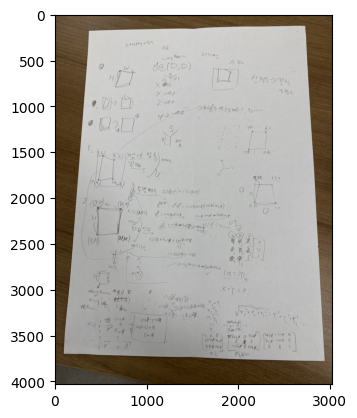

In [31]:
cv_imshow(img)

In [ ]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

cv2.drawContours(img, contours, -1, (0, 255, 0), 2)


In [ ]:
# cv2.imshow("Contours", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

this channel is 3


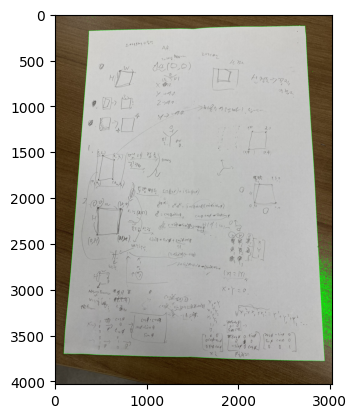

In [33]:
cv_imshow(img)

In [34]:
len(contours)

2273

In [35]:
areas = []
perimeters = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    areas.append(area)
    perimeters.append(perimeter)


개수: 2273
면적 면균: 4097.277386713595
최소 면적: 0.0
최대 면적: 9304335.5


(array([2272.]), array([     0., 100000.]), <BarContainer object of 1 artists>)

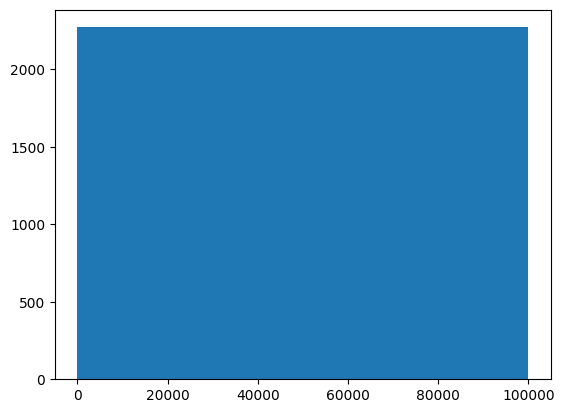

In [ ]:
print(f'개수: {len(areas)}')
print(f'면적 면균: {sum(areas)/len(areas)}')
print(f'최소 면적: {min(areas)}')
print(f'최대 면적: {max(areas)}')

In [44]:
areas = np.array(areas)
np.argmax(areas)

np.int64(2251)

numpy.ndarray

In [47]:
# contours = np.array(contours)
len(contours[np.argmax(areas).item()])

1864

(4032, 3024, 3)
this channel is 3


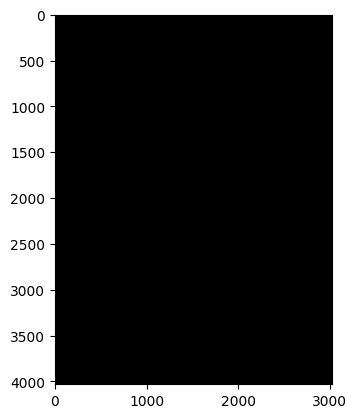

In [54]:
background = np.zeros_like(img)
print(background.shape)
cv_imshow(background)

this channel is 3


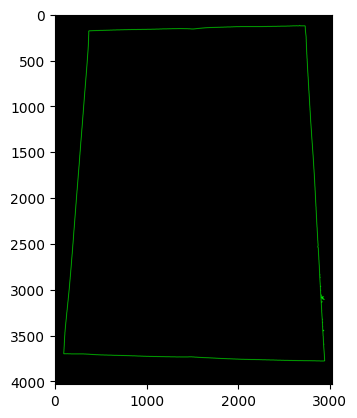

In [56]:
background = np.zeros_like(img)
cv2.drawContours(background,contours,np.argmax(areas).item(),(0,255,0),5)
cv_imshow(background)

In [57]:
cnt = contours[np.argmax(areas).item()]

In [58]:
approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)

In [59]:
approx

array([[[2720,  129]],

       [[ 367,  184]],

       [[  96, 3703]],

       [[2933, 3779]]], dtype=int32)

In [60]:
approx = approx.reshape(4,2)
for pnt in approx:
    cv2.circle(background,pnt,20,(0,0,255),-1)

this channel is 3


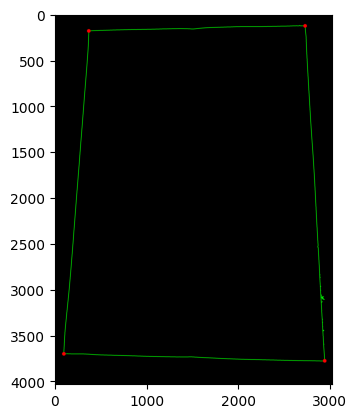

In [61]:
cv_imshow(background)